<a href="https://colab.research.google.com/github/SamuelBG-SVG/Proyecto---Grietas/blob/main/03_inclinacion_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


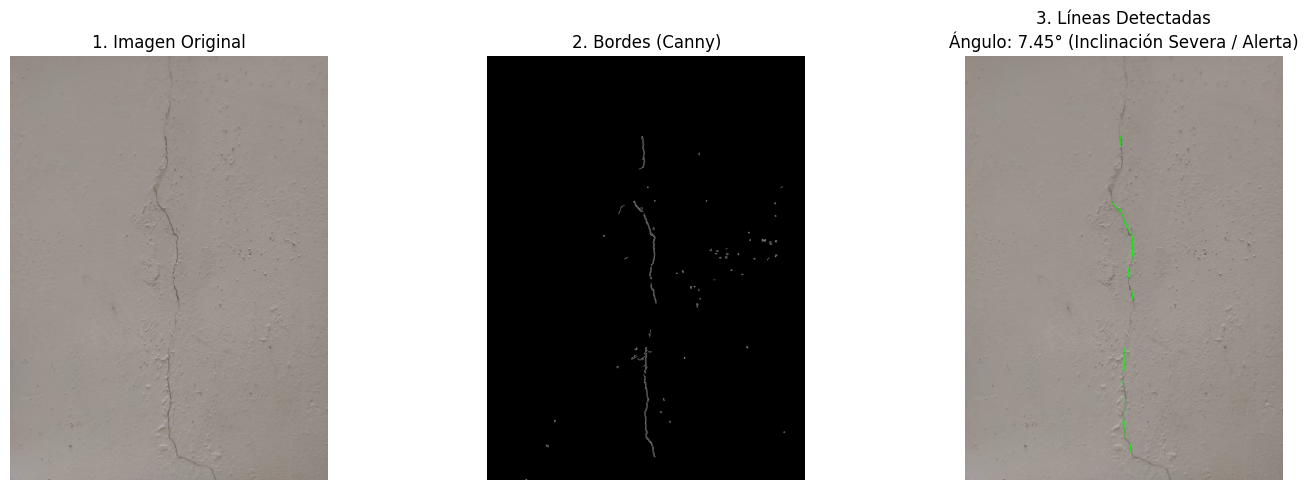

--- RESULTADO MÓDULO INCLINACIÓN ---
Líneas detectadas: 17
Ángulo promedio de desaplome: 7.45°
Diagnóstico preliminar: Inclinación Severa / Alerta



(np.float64(7.448627170934574), 'Inclinación Severa / Alerta')

In [ ]:
# ==============================================================================
# 03_inclinacion.ipynb
# Proyecto: Detección de Grietas e Inclinación Estructural (Entrega 1)
# Módulo B: Estimación de Inclinación/Desaplome con OpenCV (Ajustado)
# ==============================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import drive

# 1. Montar Google Drive
drive.mount('/content/drive')

def estimar_inclinacion_imagen(ruta_imagen, Umbral_Canny1=50, Umbral_Canny2=150):
    """
    Procesa una imagen para detectar líneas estructurales y bordes de grietas,
    calculando el ángulo de inclinación/desaplome respecto a la vertical.
    """
    img = cv2.imread(ruta_imagen)
    if img is None:
        print(f"❌ Error: No se pudo cargar la imagen en la ruta: {ruta_imagen}")
        return None

    # Convertir a escala de grises y aplicar suavizado
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # Detección de bordes con Canny
    edges = cv2.Canny(blur, Umbral_Canny1, Umbral_Canny2, apertureSize=3)

    # Detección de líneas con Transformada de Hough
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi/180,
        threshold=30,
        minLineLength=30,
        maxLineGap=10
    )

    angulos = []
    img_lineas = img.copy()

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            # Dibujar las líneas detectadas en color verde
            cv2.line(img_lineas, (x1, y1), (x2, y2), (0, 255, 0), 2)

            # Calcular ángulo respecto a la vertical
            dx = abs(x2 - x1)
            dy = abs(y2 - y1)

            if dy != 0:
                angulo_rad = np.arctan2(dx, dy)
                angulo_deg = np.degrees(angulo_rad)
                angulos.append(angulo_deg)

        angulo_promedio = np.mean(angulos) if len(angulos) > 0 else 0.0
    else:
        print("⚠️ No se detectaron líneas geométricas claras.")
        angulo_promedio = 0.0

    # Diagnóstico cualitativo
    if angulo_promedio < 2.0:
        estado = "A Plomo / Alineado"
    elif 2.0 <= angulo_promedio < 5.0:
        estado = "Inclinación Leve"
    else:
        estado = "Inclinación Severa / Alerta"

    # Mostrar resultados
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("1. Imagen Original")
    axes[0].axis("off")

    axes[1].imshow(edges, cmap='gray')
    axes[1].set_title("2. Bordes (Canny)")
    axes[1].axis("off")

    axes[2].imshow(cv2.cvtColor(img_lineas, cv2.COLOR_BGR2RGB))
    axes[2].set_title(f"3. Líneas Detectadas\nÁngulo: {angulo_promedio:.2f}° ({estado})")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"--- RESULTADO MÓDULO INCLINACIÓN ---")
    print(f"Líneas detectadas: {len(lines) if lines is not None else 0}")
    print(f"Ángulo promedio de desaplome: {angulo_promedio:.2f}°")
    print(f"Diagnóstico preliminar: {estado}\n")

    return angulo_promedio, estado

# Probar nuevamente con la foto
ruta_foto_prueba = "/content/drive/MyDrive/Proyecto_Grietas/data/Dataset_propio/Grieta_Prueba.jpeg"
estimar_inclinacion_imagen(ruta_foto_prueba)